In [ ]:
print("USING LARGE-SCALE DATASETS TO ENHANCE DIAGNOSIS IN LIMITED MULTI-SPECTRAL SKIN IMAGING")
print("Bachelor Thesis")

USING LARGE-SCALE DATASETS TO ENHANCE DIAGNOSIS IN LIMITED MULTI-SPECTRAL SKIN IMAGING
Bachelor Thesis


# Connect with Google Drive

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ngocbaotramtran
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [05:07<00:00, 18.1MB/s]


# Download all libraries and packages needed

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import cv2
import os
import shutil
import itertools
import imutils
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# import matplotlib as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torchvision.models as models
import timm
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import CosineAnnealingLR

import random
import copy
import pickle

import warnings
warnings.filterwarnings('ignore')


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
# CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
num_workers=2

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

# View Original Dataset

In [ ]:
skinDf = pd.read_csv('/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
skinDf


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [ ]:
# skinDf.columns #- To view all the columns (features) of the metadata table

In [ ]:
# skinDf['dx'].unique() #- See all the possible values of the column dx

In [ ]:
classes_to_keep = ['bcc', 'mel', 'bkl', 'nv']
skinDf = skinDf[skinDf['dx'].isin(classes_to_keep)]
skinDf['dx'].value_counts()

# when filter DataFrame = .isin(), pandas still keeps the same indexes from original DataFrame - skinDf

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514


In [ ]:
skinDf = skinDf.reset_index(drop=True)
#it will drop the old indexes - and get the new continuous indexes

In [ ]:
skinDf #view the new indexes

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
9426,HAM_0000102,ISIC_0031547,nv,consensus,20.0,male,back
9427,HAM_0000102,ISIC_0032221,nv,consensus,20.0,male,back
9428,HAM_0005314,ISIC_0030693,nv,consensus,40.0,male,neck
9429,HAM_0003322,ISIC_0031649,nv,consensus,50.0,female,face


In [ ]:
# Check NaN values
nan_count = skinDf.isnull().sum()
print("NaN values in metadata:\n", nan_count)

# Expected HAM10000 images based on metadata
expected_images = skinDf['image_id'].nunique()
print(f"\nTotal expected images from HAM10000 metadata: {expected_images}")

expected_lesions = skinDf['lesion_id'].nunique()
print(f"\nTotal expected lesion from HAM10000 metadata: {expected_lesions}")


NaN values in metadata:
 lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Total expected images from HAM10000 metadata: 9431

Total expected lesion from HAM10000 metadata: 7071


In [ ]:
# label encoding
label_map = {
    'bcc': 0,
    'bkl': 1,
    'mel': 2,
    'nv': 3
}

skinDf['label'] = skinDf['dx'].map(label_map) #label - for training -> so right now the skinDf will have one more column
print(skinDf[['dx', 'label']].head())

    dx  label
0  bkl      1
1  bkl      1
2  bkl      1
3  bkl      1
4  bkl      1


In [ ]:
img_dir1 = "/content/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
img_dir2 = "/content/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

def get_image_path(image_id):
    p1 = os.path.join(img_dir1, image_id + ".jpg")
    p2 = os.path.join(img_dir2, image_id + ".jpg")
    if os.path.exists(p1):
        return p1
    elif os.path.exists(p2):
        return p2
    else:
        return None

skinDf['image_path'] = skinDf['image_id'].apply(get_image_path)
skinDf = skinDf[skinDf['image_path'].notnull()].copy()

print("Missing image paths:", skinDf['image_path'].isnull().sum())
print("Final rows:", len(skinDf))

Missing image paths: 0
Final rows: 9431


In [ ]:
print("Columns of skinDf now:", skinDf.columns.tolist())

Columns of skinDf now: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label', 'image_path']


In [ ]:
# HAIR REMOVAL
HAIR_PIXEL_THRESHOLD = 500

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))  # kernel for blackhat # Original is (9,9) -> I changed to (7,7) -> less aggressive

hair_removed_dir = "/content/hair_removed"
os.makedirs(hair_removed_dir, exist_ok=True)

def remove_hair(row):
    image_id = row['image_id']
    save_path = os.path.join(hair_removed_dir, f"{image_id}.png")

    # If it has already been processed, skip this step (important when running again)
    if os.path.exists(save_path):
        return save_path

    img = cv2.imread(row['image_path'])
    if img is None:
        return row['image_path']  # fallback if reading error occurs

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Blackhat to find hair
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Step 3: Threshold to create a hair mask
    _, mask = cv2.threshold(blackhat, 20, 255, cv2.THRESH_BINARY) #Original the theshold(blackhat, 10, 255, cv2.THRESH_BINARY) - I changed the second parameter from 10 to 20

    hair_pixels = np.sum(mask > 0)
    if hair_pixels < HAIR_PIXEL_THRESHOLD:
        cv2.imwrite(save_path, img)  # lưu ảnh gốc không đổi
        return save_path

    # Step 4: Inpaint hair removal
    # dst_telea = cv2.inpaint(img, mask, 5, cv2.INPAINT_TELEA) #radius has been changed from 1 to 5
    dst    = cv2.inpaint(img, mask, 5, cv2.INPAINT_NS)

    cv2.imwrite(save_path, dst)
    return save_path

tqdm.pandas()
skinDf['image_path_cleaned'] = skinDf.progress_apply(remove_hair, axis=1) # So this will be commented
print("\nHair removal done!")

 87%|████████▋ | 8248/9431 [04:50<00:37, 31.31it/s]

# Change RGB images to R images, G images, B images

In [ ]:
#  R, G, B for the entire data
base_dir = "/content/multispectral_sim"
for channel in ["R", "G", "B"]:
    os.makedirs(os.path.join(base_dir, channel), exist_ok=True)

def save_rgb_channels(row):
    img = cv2.imread(row['image_path_cleaned'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_id = row['image_id']

    path_R = f"{base_dir}/R/{image_id}_R.png"
    path_G = f"{base_dir}/G/{image_id}_G.png"
    path_B = f"{base_dir}/B/{image_id}_B.png"

    cv2.imwrite(path_R, img[:, :, 0])
    cv2.imwrite(path_G, img[:, :, 1])
    cv2.imwrite(path_B, img[:, :, 2])

    return path_R, path_G, path_B

tqdm.pandas()
skinDf[['path_R', 'path_G', 'path_B']] = skinDf.progress_apply(
    save_rgb_channels, axis=1, result_type='expand'
)


100%|██████████| 9431/9431 [03:24<00:00, 46.18it/s]


In [ ]:
base_dir = "/content/multispectral_sim"

for channel in ["R", "G", "B"]:
    path = os.path.join(base_dir, channel)
    num_images = len(os.listdir(path))
    print(f"{channel}: {num_images} images")

R: 9431 images
G: 9431 images
B: 9431 images


## Original - Number of images per class - Before Split

In [ ]:
# Count the number of images by class — before and after channel separation
label_map = {
    'bcc': 0,
    'bkl': 1,
    'mel': 2,
    'nv': 3
}

print("=" * 60)
print(f"{'Class (dx)':<12} {'Label':<8} {'RGB (original)':<12} {'R':<8} {'G':<8} {'B':<8} {'Total R+G+B'}")
print("=" * 60)

for dx, label in label_map.items():
    class_df = skinDf[skinDf['dx'] == dx]

    count_rgb = len(class_df)           # number of original photos
    count_R = len(class_df['path_R'])   # = count_rgb because each image → 1 R channel
    count_G = len(class_df['path_G'])
    count_B = len(class_df['path_B'])
    total_channels = count_R + count_G + count_B

    print(f"{dx:<12} {label:<8} {count_rgb:<12} {count_R:<8} {count_G:<8} {count_B:<8} {total_channels}")

print("=" * 60)

# Total
total_rgb = len(skinDf)
total_all = total_rgb * 3
print(f"{'TOTAL':<12} {'':<8} {total_rgb:<12} {total_rgb:<8} {total_rgb:<8} {total_rgb:<8} {total_all}")

Class (dx)   Label    RGB (original) R        G        B        Total R+G+B
bcc          0        514          514      514      514      1542
bkl          1        1099         1099     1099     1099     3297
mel          2        1113         1113     1113     1113     3339
nv           3        6705         6705     6705     6705     20115
TOTAL                 9431         9431     9431     9431     28293


# After splitting

# Split the dataset - Five Fold Split

In [ ]:
def create_stratified_group_folds(df, group_col='lesion_id', label_col='label', n_splits=5):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    X = df.index.values
    y = df[label_col].values
    groups = df[group_col].values

    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
        train_fold_df = df.iloc[train_idx].reset_index(drop=True).copy()
        val_fold_df = df.iloc[val_idx].reset_index(drop=True).copy()
        folds.append((fold_idx, train_fold_df, val_fold_df))

    return folds

In [ ]:
folds = create_stratified_group_folds(skinDf, group_col='lesion_id', label_col='label', n_splits=5)

print(f"Number of folds: {len(folds)}")
for fold_idx, train_fold_df, val_fold_df in folds:
    print(f"\nFold {fold_idx+1}")
    print("Train rows:", len(train_fold_df), "| Train lesions:", train_fold_df['lesion_id'].nunique())
    print("Val rows  :", len(val_fold_df), "| Val lesions  :", val_fold_df['lesion_id'].nunique())

Number of folds: 5

Fold 1
Train rows: 7585 | Train lesions: 5656
Val rows  : 1846 | Val lesions  : 1415

Fold 2
Train rows: 7507 | Train lesions: 5656
Val rows  : 1924 | Val lesions  : 1415

Fold 3
Train rows: 7531 | Train lesions: 5657
Val rows  : 1900 | Val lesions  : 1414

Fold 4
Train rows: 7560 | Train lesions: 5657
Val rows  : 1871 | Val lesions  : 1414

Fold 5
Train rows: 7541 | Train lesions: 5658
Val rows  : 1890 | Val lesions  : 1413


In [ ]:
# Table showing the number of photos BEFORE augmentation, BY FOLD
label_map_display = {0: 'bcc', 1: 'bkl', 2: 'mel', 3: 'nv'}

for fold_idx, train_fold_df, val_fold_df in folds:
    for split_name, split_df in [("TRAIN", train_fold_df), ("VAL", val_fold_df)]:

        print(f"\nFold {fold_idx+1} — {split_name}")
        print("=" * 75)
        print(f"{'Class':<8} {'Label':<8} {'RGB':<8} {'R':<8} {'G':<8} {'B':<8} {'Total R+G+B':<14} {'%RGB'}")
        print("=" * 75)

        total_rgb = len(split_df)
        missing = []  # Add a list to track missing classes

        for label, dx in label_map_display.items():
            class_df = split_df[split_df['label'] == label]
            count_rgb = len(class_df)
            count_R   = count_rgb
            count_G   = count_rgb
            count_B   = count_rgb
            total_channels = count_R + count_G + count_B
            pct = count_rgb / total_rgb * 100 if total_rgb > 0 else 0

            print(f"{dx:<8} {label:<8} {count_rgb:<8} {count_R:<8} {count_G:<8} {count_B:<8} {total_channels:<14} {pct:.2f}%")

            if count_rgb == 0:  # check missing
                missing.append(dx)

        print("=" * 75)
        total_channels_all = total_rgb * 3

        total_pct = sum(
            len(split_df[split_df['label'] == label]) / total_rgb * 100
            for label in label_map_display.keys()
        ) if total_rgb > 0 else 0

        print(f"{'TOTAL':<8} {'':<8} {total_rgb:<8} {total_rgb:<8} {total_rgb:<8} {total_rgb:<8} {total_channels_all:<14} {total_pct:.2f}%")


        print(f"Missing classes: {missing if missing else 'None'}")


Fold 1 — TRAIN
Class    Label    RGB      R        G        B        Total R+G+B    %RGB
bcc      0        413      413      413      413      1239           5.44%
bkl      1        921      921      921      921      2763           12.14%
mel      2        896      896      896      896      2688           11.81%
nv       3        5355     5355     5355     5355     16065          70.60%
TOTAL             7585     7585     7585     7585     22755          100.00%
Missing classes: None

Fold 1 — VAL
Class    Label    RGB      R        G        B        Total R+G+B    %RGB
bcc      0        101      101      101      101      303            5.47%
bkl      1        178      178      178      178      534            9.64%
mel      2        217      217      217      217      651            11.76%
nv       3        1350     1350     1350     1350     4050           73.13%
TOTAL             1846     1846     1846     1846     5538           100.00%
Missing classes: None

Fold 2 — TRAIN
Cla

In [ ]:
for fold_idx, train_fold_df, val_fold_df in folds:
    train_lesions = set(train_fold_df['lesion_id'])
    val_lesions = set(val_fold_df['lesion_id'])

    overlap = train_lesions & val_lesions
    print(f"Fold {fold_idx+1} lesion overlap:", len(overlap))

Fold 1 lesion overlap: 0
Fold 2 lesion overlap: 0
Fold 3 lesion overlap: 0
Fold 4 lesion overlap: 0
Fold 5 lesion overlap: 0


# Metadata preprocessing

# See the distribution after selecting the attributes

In [ ]:

fig = px.bar(skinDf['dx'].value_counts(), x=skinDf['dx'].value_counts().index, y=skinDf['dx'].value_counts().values,
             labels={'x': 'Class', 'y': 'Count'}, title='Distribution of Classes') # Chart showing the number of images for each disease class
fig.show()

# Age distribution
fig = px.histogram(skinDf, x='age', title='Age Distribution') # Histogram of the patient's age
fig.show()

# Sex distribution
fig = px.bar(skinDf['sex'].value_counts(), x=skinDf['sex'].value_counts().index, y=skinDf['sex'].value_counts().values,
             labels={'x': 'Sex', 'y': 'Count'}, title='Sex Distribution') # This chart shows the number of males vs. females.
fig.show()

# Localization distribution
fig = px.bar(skinDf['localization'].value_counts(), x=skinDf['localization'].value_counts().index, y=skinDf['localization'].value_counts().values,
             labels={'x': 'Localization', 'y': 'Count'}, title='Localization Distribution') # Localization refers to the location of an injury on the body
fig.show()

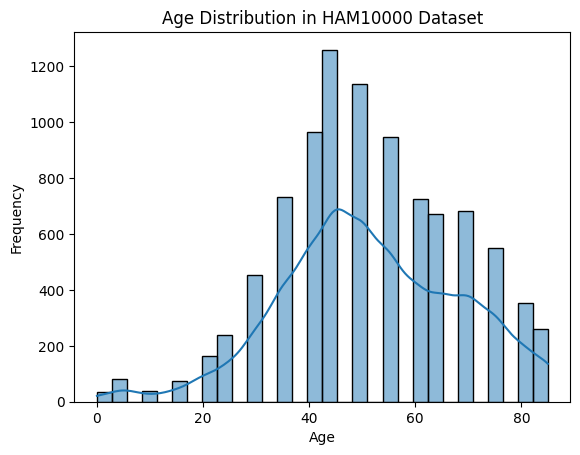

 The data is *Normal (Symmetrical). Use Mean*.


In [ ]:
# View to see - then can select mean or mode
import seaborn as sns
import scipy.stats as stats


# Histogram with KDE (Smooth Curve)
sns.histplot(skinDf['age'], bins=30, kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution in HAM10000 Dataset")
plt.show()

# Skewness Check
skewness = skinDf['age'].skew()

# Print Result
if abs(skewness) < 0.5:
    print(" The data is *Normal (Symmetrical). Use Mean*.")
elif skewness > 0.5:
    print(" The data is *Right Skewed. Use Median*.")
else:
    print(" The data is *Left Skewed. Use Median*.")

In [ ]:
def preprocess_metadata_per_fold(train_df, val_df, num_cols=['age'], cat_cols=['sex', 'localization'], target_col='label'):
    X_train_raw = train_df[num_cols + cat_cols].copy()
    X_val_raw = val_df[num_cols + cat_cols].copy()

    y_train = train_df[target_col].values
    y_val = val_df[target_col].values

    age_mean = X_train_raw['age'].mean()

    X_train_raw['age'] = X_train_raw['age'].fillna(age_mean)
    X_val_raw['age'] = X_val_raw['age'].fillna(age_mean)

    try:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

    X_train_cat = encoder.fit_transform(X_train_raw[cat_cols])
    X_val_cat = encoder.transform(X_val_raw[cat_cols])

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_raw[num_cols])
    X_val_num = scaler.transform(X_val_raw[num_cols])

    X_train_meta = np.concatenate([X_train_num, X_train_cat], axis=1)
    X_val_meta = np.concatenate([X_val_num, X_val_cat], axis=1)

    return X_train_meta, X_val_meta, y_train, y_val, encoder, scaler

# Preprocess image

In [ ]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std_range=(0.01, 0.05), p=0.5):
        self.mean = mean
        self.std_range = std_range
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            std = random.uniform(self.std_range[0], self.std_range[1])
            noise = torch.randn_like(tensor) * std + self.mean
            tensor = tensor + noise
            tensor = torch.clamp(tensor, 0.0, 1.0)
        return tensor

In [ ]:
from torchvision import transforms

# Light augmentation for all training images
train_transform_base = transforms.Compose([
    # transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15), 
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std_range=(0.01, 0.03), p=0.3), 
    transforms.Normalize(mean=[0.449],
                         std=[0.226])
])

# 0.449 ≈ mean(0.485, 0.456, 0.406)
# 0.226 ≈ mean(0.229, 0.224, 0.225)

# Stronger augmentation for minority classes only
train_transform_minority = transforms.Compose([
    # transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),  
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std_range=(0.01, 0.05), p=0.4),  
    transforms.Normalize(mean=[0.449],
                         std=[0.226]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3))  
])


# No augmentation for validation/test
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.449],
                         std=[0.226])
])

In [ ]:
minority_class_ids = {0, 1, 2}

In [ ]:
from torch.utils.data import Dataset
from PIL import Image


class HAM10000Dataset(Dataset):
    def __init__(self, df, labels,
                 base_transform=None,
                 minority_transform=None,
                 eval_transform=None,
                 minority_class_ids=None,
                 minority_aug_prob=0.7,
                 training=True):

        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.base_transform = base_transform
        self.minority_transform = minority_transform
        self.eval_transform = eval_transform
        self.minority_class_ids = minority_class_ids if minority_class_ids is not None else set()
        self.minority_aug_prob = minority_aug_prob
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Read 3 separate images of seperate channels instead of 1 RGB image
        path_R = self.df.loc[idx, 'path_R']
        path_G = self.df.loc[idx, 'path_G']
        path_B = self.df.loc[idx, 'path_B']

        # Each image is grayscale 1 channel → copy it to 3 channels so EfficientNet can receive it
        img_R = Image.open(path_R).convert('L') # convert('L')
        img_G = Image.open(path_G).convert('L')
        img_B = Image.open(path_B).convert('L')

        label = int(self.labels[idx])

        # Apply transform to each image
        if self.training:
            if (
                label in self.minority_class_ids
                and self.minority_transform is not None
                and random.random() < self.minority_aug_prob
            ):
                img_R = self.minority_transform(img_R)
                img_G = self.minority_transform(img_G)
                img_B = self.minority_transform(img_B)
            elif self.base_transform is not None:
                img_R = self.base_transform(img_R)
                img_G = self.base_transform(img_G)
                img_B = self.base_transform(img_B)
        else:
            if self.eval_transform is not None:
                img_R = self.eval_transform(img_R)
                img_G = self.eval_transform(img_G)
                img_B = self.eval_transform(img_B)

        label = torch.tensor(label, dtype=torch.long)

        # Return 3 separate images instead of 1
        return img_R, img_G, img_B, label

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

def build_loaders_for_fold(train_df, val_df, batch_size=32):
    y_train = train_df['label'].values
    y_val = val_df['label'].values

    train_dataset = HAM10000Dataset(
        df=train_df,
        labels=y_train,
        base_transform=train_transform_base,
        minority_transform=train_transform_minority,
        eval_transform=None,
        minority_class_ids={0, 1, 2},
        minority_aug_prob=0.7,
        training=True
    )

    val_dataset = HAM10000Dataset(
        df=val_df,
        labels=y_val,
        eval_transform=eval_transform,
        training=False
    )

    num_classes = len(np.unique(y_train))
    class_counts = np.bincount(y_train, minlength=num_classes)
    class_counts = np.maximum(class_counts, 1)

    class_weights = class_counts.sum() / (num_classes * class_counts)
    sample_weights = class_weights[y_train]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        drop_last=True,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g
    )

    return train_loader, val_loader  # ← bỏ metadata_dim

In [ ]:
fold_idx, train_df, val_df = folds[0]

train_loader, val_loader = build_loaders_for_fold(
    train_df, val_df, batch_size=32
)

# Simulation to see the distribution - images per class for each fold
Table showing the number of images after augmentation by class.

In [ ]:
label_map_display = {0: 'bcc', 1: 'bkl', 2: 'mel', 3: 'nv'}

# Uncomment these codes below to see the simulation of the distribution
# for fold_idx, train_fold_df, val_fold_df in folds:
#     train_loader_check, _, _ = build_loaders_for_fold(
#         train_fold_df, val_fold_df, batch_size=32
#     )

#     label_counts = [0, 0, 0, 0]
#     for img_R, img_G, img_B, meta, labels in train_loader_check:
#         for l in labels:
#             label_counts[l.item()] += 1

#     total = sum(label_counts)
#     print(f"\nFold {fold_idx+1} — TRAIN (Actual number after WeightedRandomSampler, 1 epoch)")
#     print("=" * 55)
#     print(f"{'Class':<8} {'Count':<10} {'%'}")
#     print("=" * 55)
#     for label, dx in label_map_display.items():
#         count = label_counts[label]
#         print(f"{dx:<8} {count:<10} {count/total*100:.1f}%")
#     print("=" * 55)
#     print(f"{'TOTAL':<8} {total}")

In [ ]:
img_R, img_G, img_B, labels = next(iter(train_loader))
print(img_R.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 1, 300, 300])
torch.Size([32])
tensor([1, 1, 1, 1, 0, 2, 3, 3, 1, 1])


In [ ]:
from PIL import Image

# label names for display
label_names = {
    0: 'bcc',
    1: 'bkl',
    2: 'mel',
    3: 'nv'
}

minority_class_ids = {0, 1, 2}
minority_aug_prob = 0.7

def denormalize(img_tensor, mean=0.449, std=0.226):
    img = img_tensor.clone().detach().cpu().numpy().squeeze()
    # (1,H,W) → (H,W) ← squeeze() remove dimension = 1
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmentation_example(df, index=None, n_aug=3):
    if index is None:
        index = np.random.randint(0, len(df))

    row = df.iloc[index]
    img_path = row['image_path_cleaned']
    label = int(row['label'])

    image = Image.open(img_path).convert("L")

    plt.figure(figsize=(4 * (n_aug + 1), 4))

    # original image
    plt.subplot(1, n_aug + 1, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original\n{label_names[label]}")
    plt.axis("off")

    # augmented versions
    for i in range(n_aug):
        if label in minority_class_ids and random.random() < minority_aug_prob:
            transform = train_transform_minority
            transform_name = "Minority Transform"
        else:
            transform = train_transform_base
            transform_name = "Base Transform"

        aug_tensor = transform(image)
        aug_img = denormalize(aug_tensor)

        plt.subplot(1, n_aug + 1, i + 2)
        plt.imshow(aug_img, cmap='gray')
        plt.title(f"{transform_name}\nAug {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

In [ ]:
batch = next(iter(train_loader))
img_R, img_G, img_B, labels = batch

print("images shape   :", img_R.shape)
print("labels shape   :", labels.shape)
print("labels dtype   :", labels.dtype)
print("unique labels  :", torch.unique(labels))

images shape   : torch.Size([32, 1, 300, 300])
labels shape   : torch.Size([32])
labels dtype   : torch.int64
unique labels  : tensor([0, 1, 2, 3])


In [ ]:
def make_single_channel_efficientnet(pretrained=True):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    backbone = models.efficientnet_b0(weights=weights)

    # First conv of EfficientNet-B0: Conv2d(3, 32, kernel_size=3, stride=2)
    old_conv = backbone.features[0][0]  # Original Conv2d(3, 32, ...)

    # Creating a new conv will get 1 channel instead of 3.
    new_conv = nn.Conv2d(
        in_channels=1,          # Change from 3 to 1
        out_channels=old_conv.out_channels,   # 32
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None
    )

    # Initialize weights: average the 3 original channels into 1.
    # Retain pretrained knowledge instead of random init
    with torch.no_grad():
        new_conv.weight = nn.Parameter(
            old_conv.weight.mean(dim=1, keepdim=True)  # (32,3,3,3) → (32,1,3,3)
        )

    # Replace first conv
    backbone.features[0][0] = new_conv

    return backbone.features  # only get feature extractor

In [ ]:
class ImageOnlySkinNet(nn.Module):
    """Image-only model, no metadata"""
    def __init__(self, num_classes=4, pretrained_model=None):
        super().__init__()

        if pretrained_model is not None:
            self.shared_backbone = pretrained_model.shared_backbone
            self.pool = pretrained_model.pool
            self.img_dropout = pretrained_model.img_dropout
        else:
            self.shared_backbone = make_single_channel_efficientnet(pretrained=True)
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.img_dropout = nn.Dropout(0.5)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def extract(self, img):
        return torch.flatten(self.pool(self.shared_backbone(img)), 1)

    def forward(self, img_R, img_G, img_B):
        feat_R = self.extract(img_R)
        feat_G = self.extract(img_G)
        feat_B = self.extract(img_B)

        img_feat = torch.cat([feat_R, feat_G, feat_B], dim=1)
        img_feat = self.img_dropout(img_feat)

        return self.classifier(img_feat)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for img_R, img_G, img_B, labels in loader:
        img_R = img_R.to(device)
        img_G = img_G.to(device)
        img_B = img_B.to(device)

        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(img_R, img_G, img_B)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * img_R.size(0)  # change images → img_R

        # img_R = img_G = img_B

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1

In [ ]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_B, labels in loader:
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_B = img_B.to(device)

            labels = labels.to(device).long()

            outputs = model(img_R, img_G, img_B)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * img_R.size(0)  

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1

In [ ]:
num_classes = int(skinDf['label'].nunique())
# num_epochs = 30
fold_results = []

all_fold_train_losses = []
all_fold_val_losses = []

all_fold_train_accs = []
all_fold_val_accs = []

all_fold_train_bal_accs = []
all_fold_val_bal_accs = []

all_fold_train_f1s = []
all_fold_val_f1s = []

for fold_idx, train_fold_df, val_fold_df in folds:
    print(f"\n{'='*60}")
    print(f"Starting Fold {fold_idx+1}/{len(folds)}")
    print(f"{'='*60}")

    train_loader, val_loader = build_loaders_for_fold(
        train_fold_df, val_fold_df, batch_size=32
    )

    criterion = nn.CrossEntropyLoss()

    # ======================================================
    # Freeze the entire backbone, only train the head.
    # ======================================================
    print("\n--- Phase 1: Training head only (5 epochs) ---")

    model = ImageOnlySkinNet(
        num_classes=num_classes,
        pretrained_model=None  # hoặc bỏ parameter này
    ).to(device)

        # Freeze backbone
    for param in model.shared_backbone.parameters():
        param.requires_grad = False

    # Only train classifier
    head_params = list(model.classifier.parameters())

    optimizer_p1 = optim.Adam(head_params, lr=1e-4)

    for epoch in range(5):
        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer_p1, device
        )
        val_loss, val_acc, val_bal_acc, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )
        print(
            f"  [P1] Epoch {epoch+1}/5 | "
            f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}"
        )

    # ======================================================
    # Unfreeze the last 2 blocks, fine-tune everything
    # ======================================================
    print("\n--- Phase 2: Fine-tuning last 2 blocks (50 epochs) ---")

    # Unfreeze 2 last blocks of backbone
    blocks = list(model.shared_backbone.children())
    for block in blocks[-2:]:
        for param in block.parameters():
            param.requires_grad = True

    # Separate the parameters with different lr values.
    backbone_params = [
        p for p in model.shared_backbone.parameters()
        if p.requires_grad
    ]

    head_params = list(model.classifier.parameters())

    optimizer_p2 = optim.AdamW([
        {"params": backbone_params, "lr": 3e-5},  # 1e-5 → 3e-5
        {"params": head_params,     "lr": 1e-4},
    ], weight_decay=2e-4, betas=(0.9, 0.999))    # 5e-4 → 1e-4

    scheduler = CosineAnnealingWarmRestarts(
        optimizer_p2, T_0=10, T_mult=2, eta_min=1e-7
    )

    # Early stopping settings
    patience = 9
    min_delta = 0.001
    best_val_f1 = -float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    best_model_state = None

    fold_train_losses = []
    fold_val_losses = []
    fold_train_accs = []
    fold_val_accs = []
    fold_train_bal_accs = []
    fold_val_bal_accs = []
    fold_train_f1s = []
    fold_val_f1s = []

    for epoch in range(50):
        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer_p2, device
        )
        val_loss, val_acc, val_bal_acc, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        scheduler.step()   # ← decrease lr when plateauing

        # Add log
        backbone_lr = optimizer_p2.param_groups[0]['lr']
        head_lr = optimizer_p2.param_groups[1]['lr']

        #

        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)
        fold_train_bal_accs.append(train_bal_acc)
        fold_train_f1s.append(train_f1)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)
        fold_val_bal_accs.append(val_bal_acc)
        fold_val_f1s.append(val_f1)

        print(
            f"Epoch [{epoch+1}/50] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Train Bal Acc: {train_bal_acc:.4f} | Train Macro F1: {train_f1:.4f} || "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Bal Acc: {val_bal_acc:.4f} | Val Macro F1: {val_f1:.4f} | "
            f"LR: backbone={backbone_lr:.2e}, head={head_lr:.2e}"
        )

        # Early stopping
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch
            epochs_without_improvement = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"  -> New best val_macro_f1: {best_val_f1:.4f}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement}/{patience} epoch(s)")

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # Restore best weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)



    # FULL CHECKPOINT (THAY THẾ DÒNG CŨ)
    checkpoint = {
        'model_state_dict': best_model_state,
        'num_classes': num_classes,
        'best_epoch': best_epoch + 1,  # +1 because epoch starts from 0
        'best_val_f1': best_val_f1,
        'best_val_acc': fold_val_accs[best_epoch],
        'best_val_bal_acc': fold_val_bal_accs[best_epoch],
        'best_val_loss': fold_val_losses[best_epoch],
        'fold': fold_idx + 1
    }
    checkpoint_path = f'checkpoint_fold_{fold_idx+1}.pth'
    torch.save(checkpoint, checkpoint_path)
    print(f"Saved full checkpoint to: {checkpoint_path}")



    # Still keep simple FILE WEIGHTS (OPTIONAL)
    weights_path = f'best_model_fold_{fold_idx+1}.pth'
    torch.save(best_model_state, weights_path)
    print(f" Saved model weights to: {weights_path}")


    fold_results.append({
        "fold": fold_idx + 1,
        "train_losses": fold_train_losses,
        "val_losses": fold_val_losses,
        "train_accs": fold_train_accs,
        "val_accs": fold_val_accs,
        "train_bal_accs": fold_train_bal_accs,
        "val_bal_accs": fold_val_bal_accs,
        "train_f1s": fold_train_f1s,
        "val_f1s": fold_val_f1s,
        "stopped_epoch": len(fold_val_f1s),
        "best_epoch": best_epoch + 1,
        "final_val_loss": fold_val_losses[-1],
        "final_val_acc": fold_val_accs[-1],
        "final_val_bal_acc": fold_val_bal_accs[-1],
        "final_val_f1": fold_val_f1s[-1],
        "best_val_loss": fold_val_losses[best_epoch],
        "best_val_acc": fold_val_accs[best_epoch],
        "best_val_bal_acc": fold_val_bal_accs[best_epoch],
        "best_val_f1": fold_val_f1s[best_epoch]
    })

    all_fold_train_losses.append(fold_train_losses)
    all_fold_val_losses.append(fold_val_losses)
    all_fold_train_accs.append(fold_train_accs)
    all_fold_val_accs.append(fold_val_accs)
    all_fold_train_bal_accs.append(fold_train_bal_accs)
    all_fold_val_bal_accs.append(fold_val_bal_accs)
    all_fold_train_f1s.append(fold_train_f1s)
    all_fold_val_f1s.append(fold_val_f1s)


Starting Fold 1/5

--- Phase 1: Training head only (5 epochs) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 231MB/s]


  [P1] Epoch 1/5 | Train F1: 0.5073 | Val F1: 0.5725
  [P1] Epoch 2/5 | Train F1: 0.5922 | Val F1: 0.6007
  [P1] Epoch 3/5 | Train F1: 0.6276 | Val F1: 0.6123
  [P1] Epoch 4/5 | Train F1: 0.6365 | Val F1: 0.6361
  [P1] Epoch 5/5 | Train F1: 0.6482 | Val F1: 0.6380

--- Phase 2: Fine-tuning last 2 blocks (50 epochs) ---
Epoch [1/50] | Train Loss: 0.8272 | Train Acc: 0.6556 | Train Bal Acc: 0.6535 | Train Macro F1: 0.6510 || Val Loss: 0.6005 | Val Acc: 0.7616 | Val Bal Acc: 0.7007 | Val Macro F1: 0.6336 | LR: backbone=2.93e-05, head=9.76e-05
  -> New best val_macro_f1: 0.6336
Epoch [2/50] | Train Loss: 0.7834 | Train Acc: 0.6750 | Train Bal Acc: 0.6765 | Train Macro F1: 0.6744 || Val Loss: 0.5366 | Val Acc: 0.7784 | Val Bal Acc: 0.6772 | Val Macro F1: 0.6439 | LR: backbone=2.71e-05, head=9.05e-05
  -> New best val_macro_f1: 0.6439
Epoch [3/50] | Train Loss: 0.7601 | Train Acc: 0.6926 | Train Bal Acc: 0.6925 | Train Macro F1: 0.6910 || Val Loss: 0.5376 | Val Acc: 0.7730 | Val Bal Acc: 0.6

In [ ]:
# ============================================================
# XEM THÔNG TIN CHECKPOINT
# ============================================================

def inspect_checkpoint(fold_num=1):
    """Print checkpoint information"""
    import torch
    import pickle

    # Load checkpoint
    checkpoint = torch.load(f'checkpoint_fold_{fold_num}.pth', map_location='cpu')

    print(f"\n{'='*60}")
    print(f"CHECKPOINT FOLD {fold_num}")
    print(f"{'='*60}")
    for key, value in checkpoint.items():
        if key != 'model_state_dict':
            print(f"{key:20s}: {value}")
    print(f"{'='*60}\n")

    # Load preprocessing
    preprocessing = pickle.load(open(f'preprocessing_fold_{fold_num}.pkl', 'rb'))

    print(f"{'='*60}")
    print(f"PREPROCESSING FOLD {fold_num}")
    print(f"{'='*60}")
    for key, value in preprocessing.items():
        if key not in ['encoder', 'scaler']:
            print(f"{key:20s}: {value}")
        else:
            print(f"{key:20s}: {type(value).__name__}")
    print(f"{'='*60}\n")

# Usage:
# inspect_checkpoint(fold_num=1)

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_B, labels in dataloader:
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_B = img_B.to(device)

            labels = labels.to(device).long()

            outputs = model(img_R, img_G, img_B)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, bal_acc, precision, recall, f1, cm, all_labels, all_preds

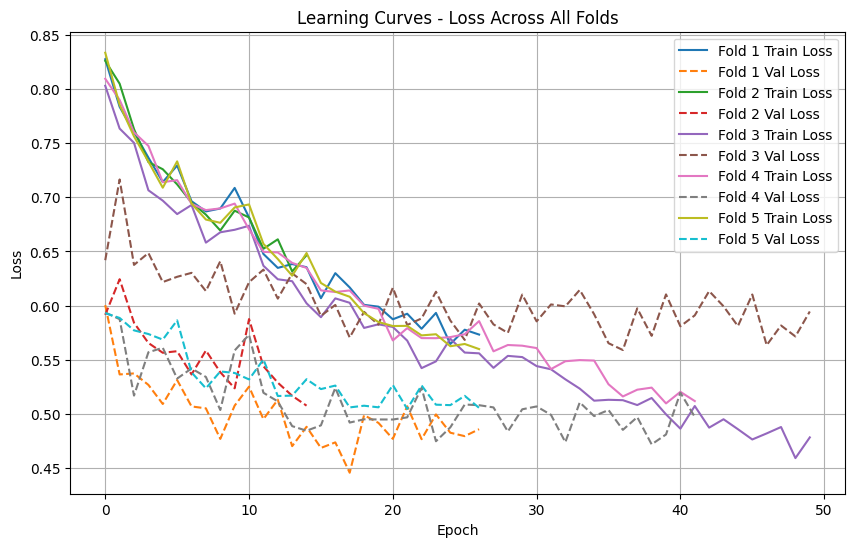

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_losses)):
    plt.plot(all_fold_train_losses[i], label=f"Fold {i+1} Train Loss")
    plt.plot(all_fold_val_losses[i], linestyle='--', label=f"Fold {i+1} Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves - Loss Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

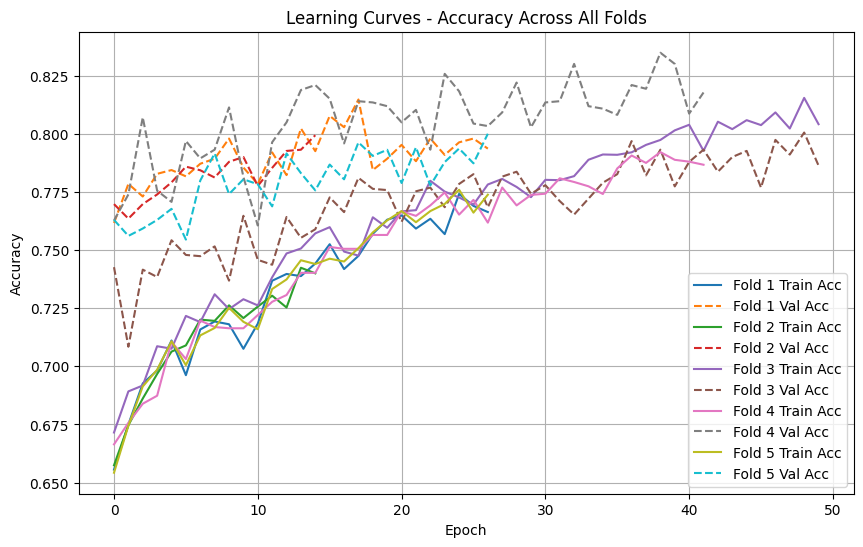

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_accs)):
    plt.plot(all_fold_train_accs[i], label=f"Fold {i+1} Train Acc")
    plt.plot(all_fold_val_accs[i], linestyle='--', label=f"Fold {i+1} Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curves - Accuracy Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

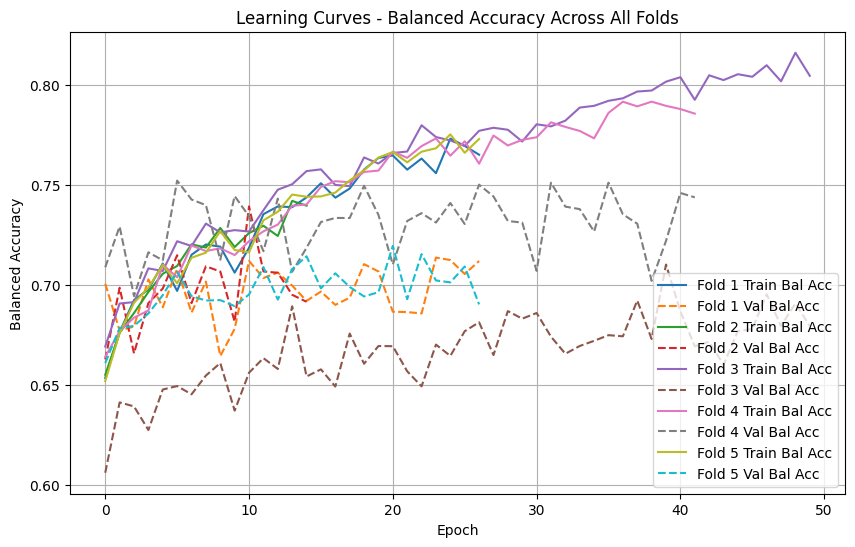

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_bal_accs)):
    plt.plot(all_fold_train_bal_accs[i], label=f"Fold {i+1} Train Bal Acc")
    plt.plot(all_fold_val_bal_accs[i], linestyle='--', label=f"Fold {i+1} Val Bal Acc")

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Learning Curves - Balanced Accuracy Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

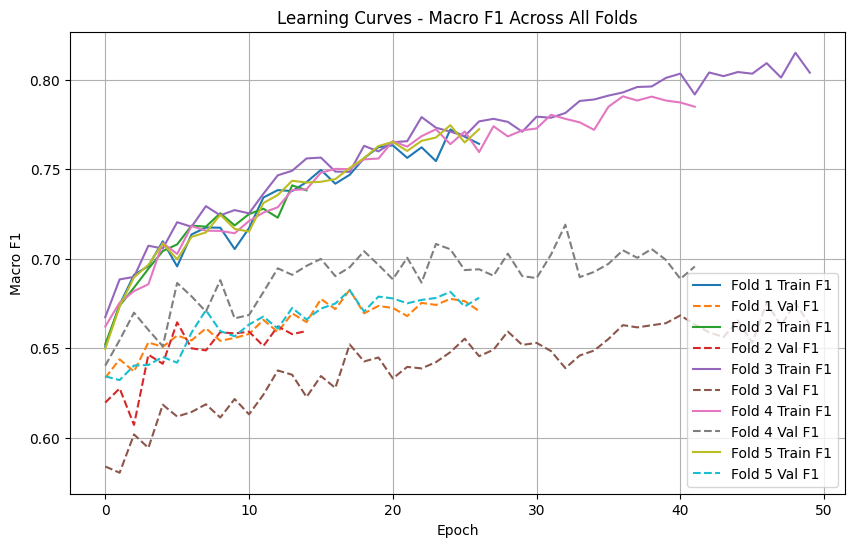

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_f1s)):
    plt.plot(all_fold_train_f1s[i], label=f"Fold {i+1} Train F1")
    plt.plot(all_fold_val_f1s[i], linestyle='--', label=f"Fold {i+1} Val F1")

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Learning Curves - Macro F1 Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

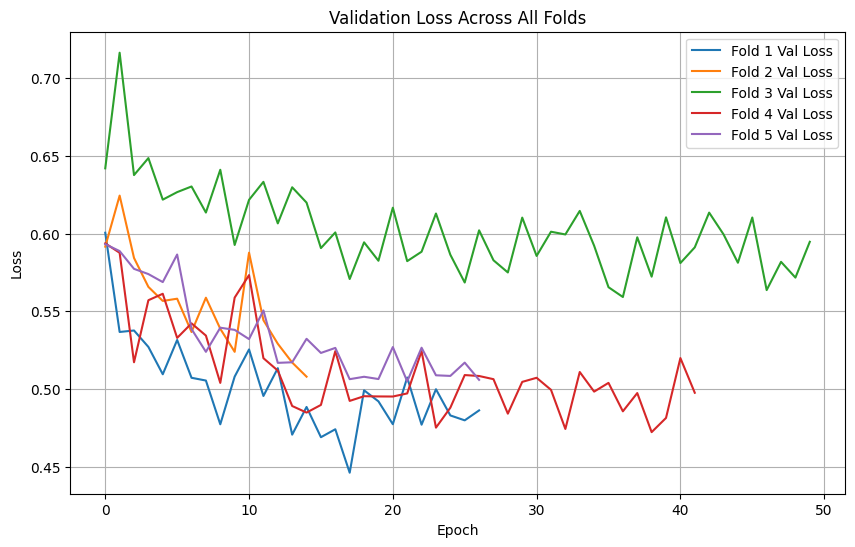

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(len(all_fold_val_losses)):
    plt.plot(all_fold_val_losses[i], label=f"Fold {i+1} Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

def plot_roc_curve(model, loader, device, label_names):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_B, labels in loader:  
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_B = img_B.to(device)

            outputs = model(img_R, img_G, img_B)
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    n_classes = len(label_names)
    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def compute_log_loss(model, loader, device):
    from sklearn.metrics import log_loss

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_B, labels in loader:  
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_B = img_B.to(device)

            outputs = model(img_R, img_G, img_B)
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    loss = log_loss(all_labels, all_probs)
    print(f"Log Loss: {loss:.4f}")
    return loss

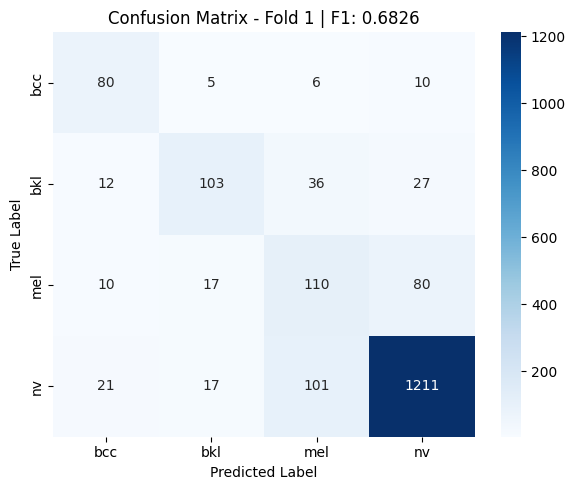


Fold 1 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.6504    0.7921    0.7143       101
         bkl     0.7254    0.5787    0.6438       178
         mel     0.4348    0.5069    0.4681       217
          nv     0.9119    0.8970    0.9044      1350

    accuracy                         0.8147      1846
   macro avg     0.6806    0.6937    0.6826      1846
weighted avg     0.8235    0.8147    0.8176      1846

Cohen's Kappa: 0.5853
MCC:           0.5860


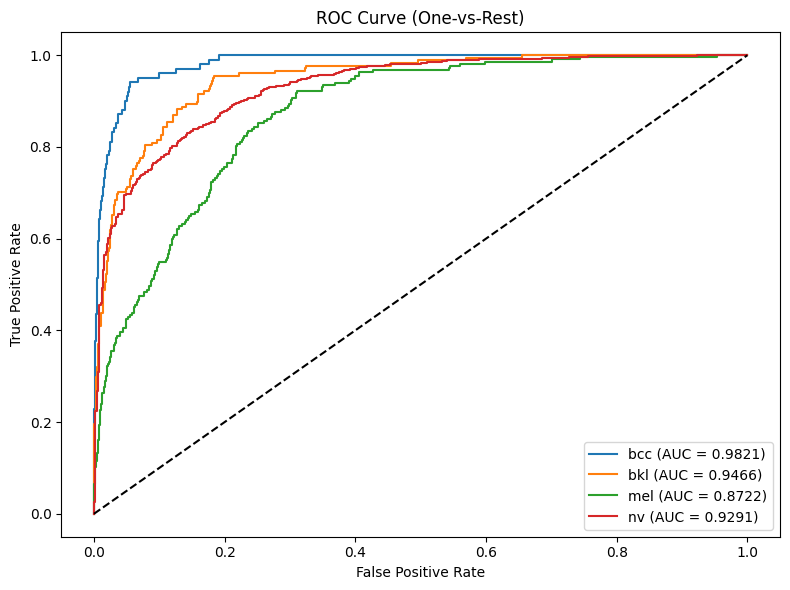

Log Loss: 0.4460


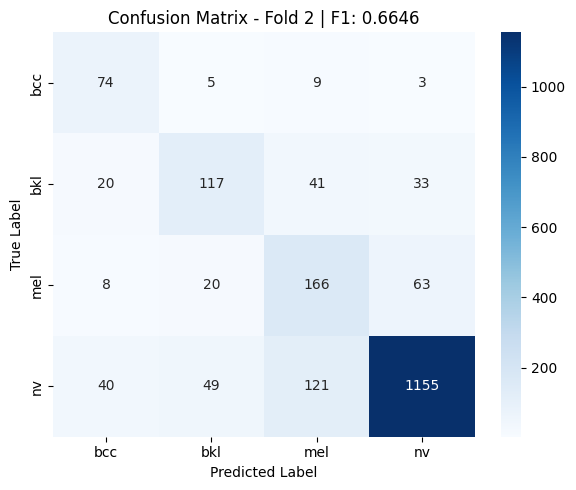


Fold 2 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.5211    0.8132    0.6352        91
         bkl     0.6126    0.5545    0.5821       211
         mel     0.4926    0.6459    0.5589       257
          nv     0.9211    0.8462    0.8820      1365

    accuracy                         0.7859      1924
   macro avg     0.6368    0.7149    0.6646      1924
weighted avg     0.8111    0.7859    0.7943      1924

Cohen's Kappa: 0.5716
MCC:           0.5762


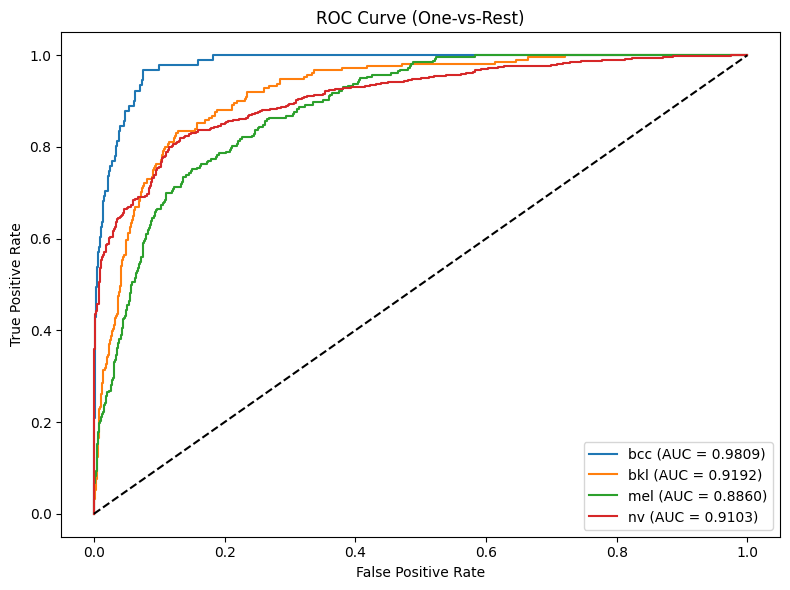

Log Loss: 0.5580


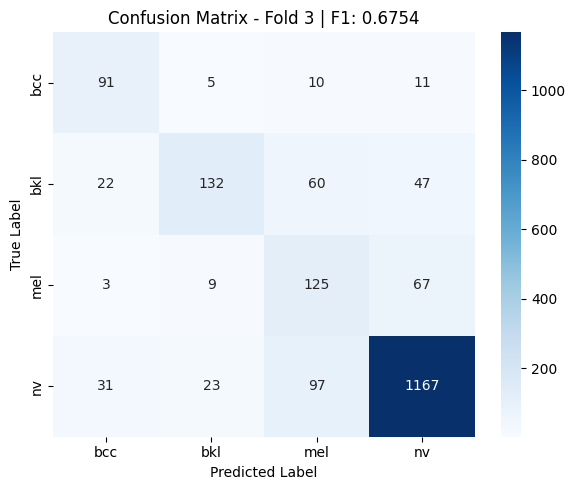


Fold 3 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.6190    0.7778    0.6894       117
         bkl     0.7811    0.5057    0.6140       261
         mel     0.4281    0.6127    0.5040       204
          nv     0.9033    0.8854    0.8943      1318

    accuracy                         0.7974      1900
   macro avg     0.6829    0.6954    0.6754      1900
weighted avg     0.8179    0.7974    0.8012      1900

Cohen's Kappa: 0.5905
MCC:           0.5935


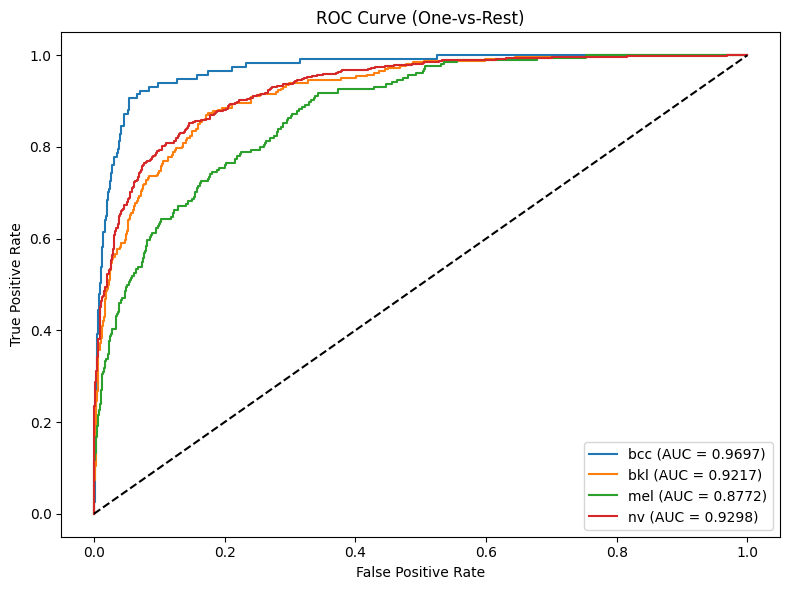

Log Loss: 0.5636


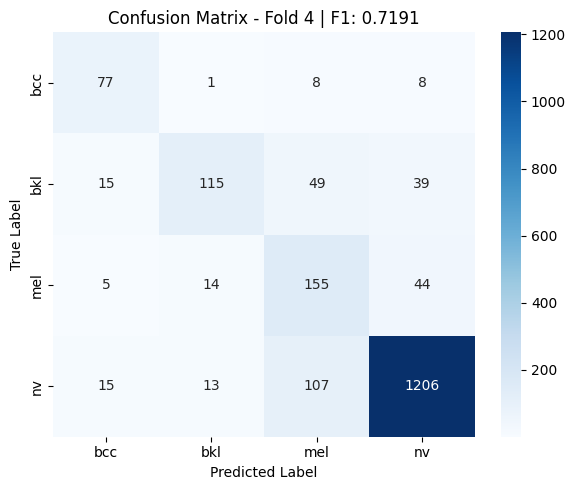


Fold 4 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.6875    0.8191    0.7476        94
         bkl     0.8042    0.5275    0.6371       218
         mel     0.4859    0.7110    0.5773       218
          nv     0.9298    0.8993    0.9143      1341

    accuracy                         0.8300      1871
   macro avg     0.7269    0.7393    0.7191      1871
weighted avg     0.8513    0.8300    0.8344      1871

Cohen's Kappa: 0.6394
MCC:           0.6432


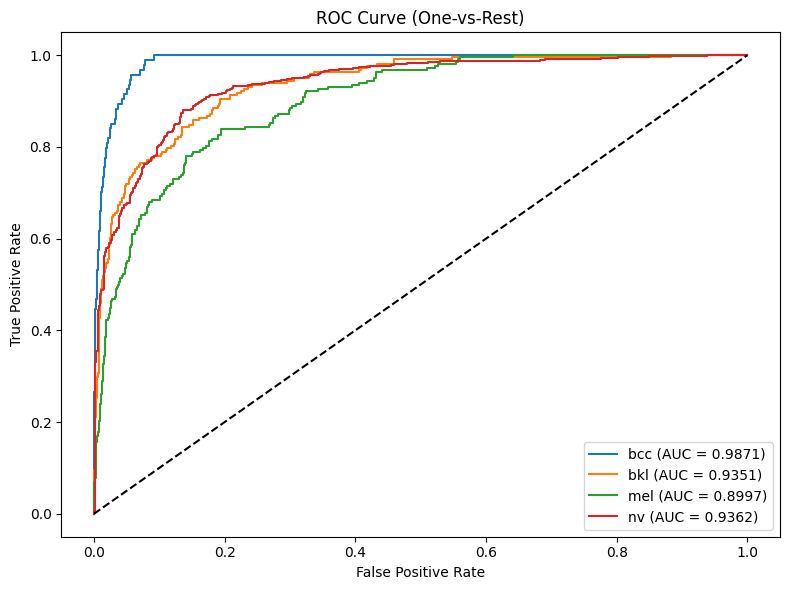

Log Loss: 0.4742


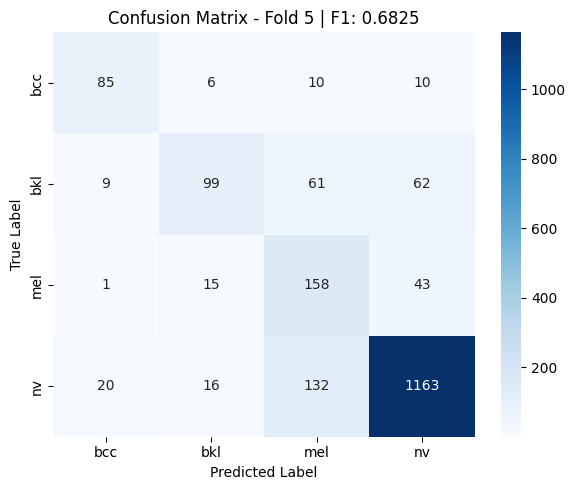


Fold 5 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.7391    0.7658    0.7522       111
         bkl     0.7279    0.4286    0.5395       231
         mel     0.4377    0.7281    0.5467       217
          nv     0.9100    0.8738    0.8915      1331

    accuracy                         0.7963      1890
   macro avg     0.7037    0.6991    0.6825      1890
weighted avg     0.8235    0.7963    0.8007      1890

Cohen's Kappa: 0.5839
MCC:           0.5895


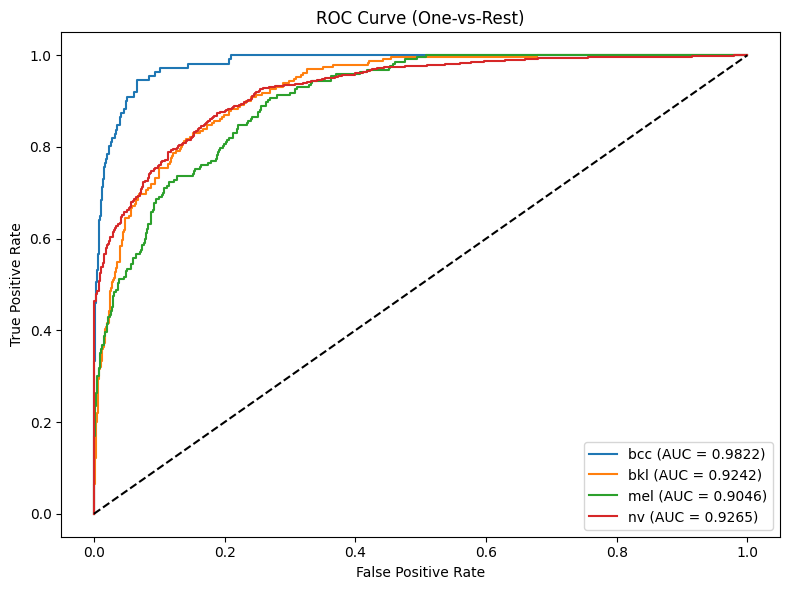

Log Loss: 0.5062


In [ ]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, classification_report
import seaborn as sns


label_names = ['bcc', 'bkl', 'mel', 'nv']


# ✅ Định nghĩa hàm ngay tại đây
def extra_metrics(all_labels, all_preds):
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"MCC:           {mcc:.4f}")
    return kappa, mcc

for fr in fold_results:
    fold_idx = fr['fold'] - 1
    _, train_fold_df, val_fold_df = folds[fold_idx]
    train_loader, val_loader = build_loaders_for_fold(train_fold_df, val_fold_df)

    model_eval = ImageOnlySkinNet(num_classes=4).to(device)
    model_eval.load_state_dict(torch.load(f"best_model_fold_{fr['fold']}.pth", map_location=device))

    acc, bal_acc, precision, recall, f1, cm, all_labels, all_preds = evaluate_model(
        model_eval, val_loader, device
    )

    # confusion matrix


    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_names, yticklabels=label_names, cmap='Blues')
    plt.title(f"Confusion Matrix - Fold {fr['fold']} | F1: {f1:.4f}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"\nFold {fr['fold']} — Per-class metrics:")
    print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))

    kappa, mcc = extra_metrics(all_labels, all_preds)
    plot_roc_curve(model_eval, val_loader, device, label_names)
    compute_log_loss(model_eval, val_loader, device)

In [ ]:
print(f"\n{'='*60}")
print("FINAL RESULTS ACROSS ALL FOLDS")
print(f"{'='*60}")
print(f"{'Fold':<8} {'Best Epoch':<12} {'Val Acc':<10} {'Val Bal Acc':<14} {'Val F1'}")
print(f"{'='*60}")
for fr in fold_results:
    print(f"{fr['fold']:<8} {fr['best_epoch']:<12} {fr['best_val_acc']:.4f}     {fr['best_val_bal_acc']:.4f}         {fr['best_val_f1']:.4f}")
print(f"{'='*60}")
best_f1s = [fr['best_val_f1'] for fr in fold_results]
best_accs = [fr['best_val_acc'] for fr in fold_results]
print(f"Mean F1:  {np.mean(best_f1s):.4f} ± {np.std(best_f1s):.4f}")
print(f"Mean Acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")


FINAL RESULTS ACROSS ALL FOLDS
Fold     Best Epoch   Val Acc    Val Bal Acc    Val F1
1        18           0.8147     0.6937         0.6826
2        6            0.7859     0.7149         0.6646
3        47           0.7974     0.6954         0.6754
4        33           0.8300     0.7393         0.7191
5        18           0.7963     0.6991         0.6825
Mean F1:  0.6848 ± 0.0183
Mean Acc: 0.8049 ± 0.0156


In [ ]:
print(f"\n{'='*60}")
print("FINAL RESULTS ACROSS ALL FOLDS")
print(f"{'='*60}")
print(f"{'Fold':<8} {'Best Epoch':<12} {'Val Acc':<10} {'Val Bal Acc':<14} {'Val F1'}")
print(f"{'='*60}")
for fr in fold_results:
    print(f"{fr['fold']:<8} {fr['best_epoch']:<12} {fr['best_val_acc']:.4f}     {fr['best_val_bal_acc']:.4f}         {fr['best_val_f1']:.4f}")
print(f"{'='*60}")
best_f1s = [fr['best_val_f1'] for fr in fold_results]
best_accs = [fr['best_val_acc'] for fr in fold_results]
print(f"Mean F1:  {np.mean(best_f1s):.4f} ± {np.std(best_f1s):.4f}")
print(f"Mean Acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")


FINAL RESULTS ACROSS ALL FOLDS
Fold     Best Epoch   Val Acc    Val Bal Acc    Val F1
1        18           0.8147     0.6937         0.6826
2        6            0.7859     0.7149         0.6646
3        47           0.7974     0.6954         0.6754
4        33           0.8300     0.7393         0.7191
5        18           0.7963     0.6991         0.6825
Mean F1:  0.6848 ± 0.0183
Mean Acc: 0.8049 ± 0.0156


---